In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tpqoa
from datetime import datetime, timezone, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
class SMATrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, SMA_S, SMA_L, units):
        super().__init__(conf_file)
        self.instrument = instrument
        self.bar_length = pd.to_timedelta(bar_length)
        self.tick_data = pd.DataFrame()
        self.raw_data = None
        self.data = None
        self.last_bar = None
        self.units = units
        self.position = 0
        self.profits = []

        #*****************add strategy-specific attributes here******************
        self.SMA_S = SMA_S
        self.SMA_L = SMA_L
        #************************************************************************

    def get_most_recent(self, days = 5):
        while True:
            time.sleep(2)
            now = datetime.now(timezone.utc).replace(tzinfo=None)
            now = now - timedelta(microseconds = now.microsecond)
            past = now - timedelta(days = days)
            df = self.get_history(instrument = self.instrument, start = past, end = now,
                                   granularity = "S5", price = "M", localize = False).c.dropna().to_frame()
            df.rename(columns = {"c":self.instrument}, inplace = True)
            df = df.resample(self.bar_length, label = "right").last().dropna().iloc[:-1]
            self.raw_data = df.copy()
            self.last_bar = self.raw_data.index[-1]
            if pd.to_datetime(datetime.now(timezone.utc)) - self.last_bar < self.bar_length:
                break

    def on_success(self, time, bid, ask):
        print(self.ticks, end = " ")

        recent_tick = pd.to_datetime(time)
        df = pd.DataFrame({self.instrument:(ask + bid)/2},
                          index = [recent_tick])
        self.tick_data = pd.concat([self.tick_data, df]) # new with pd.concat()

        if recent_tick - self.last_bar > self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.execute_trades()

    def resample_and_join(self):
        self.raw_data = pd.concat([self.raw_data, self.tick_data.resample(self.bar_length,
                                                                          label="right").last().ffill().iloc[:-1]])
        self.tick_data = self.tick_data.iloc[-1:]
        self.last_bar = self.raw_data.index[-1]

    def define_strategy(self): # "strategy-specific"
        df = self.raw_data.copy()

        #******************** define your strategy here ************************
        df["SMA_S"] = df[self.instrument].rolling(self.SMA_S).mean()
        df["SMA_L"] = df[self.instrument].rolling(self.SMA_L).mean()
        df["position"] = np.where(df["SMA_S"] > df["SMA_L"], 1, -1)
        #***********************************************************************

        self.data = df.copy()

    def execute_trades(self):
        if self.data["position"].iloc[-1] == 1:
            if self.position == 0:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            elif self.position == -1:
                order = self.create_order(self.instrument, self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING LONG")
            self.position = 1
        elif self.data["position"].iloc[-1] == -1:
            if self.position == 0:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units * 2, suppress = True, ret = True)
                self.report_trade(order, "GOING SHORT")
            self.position = -1
        elif self.data["position"].iloc[-1] == 0:
            if self.position == -1:
                order = self.create_order(self.instrument, self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")
            elif self.position == 1:
                order = self.create_order(self.instrument, -self.units, suppress = True, ret = True)
                self.report_trade(order, "GOING NEUTRAL")
            self.position = 0

    def report_trade(self, order, going):
        time = order["time"]
        units = order["units"]
        price = order["price"]
        pl = float(order["pl"])
        self.profits.append(pl)
        cumpl = sum(self.profits)
        print("\n" + 100* "-")
        print("{} | {}".format(time, going))
        print("{} | units = {} | price = {} | P&L = {} | Cum P&L = {}".format(time, units, price, pl, cumpl))
        print(100 * "-" + "\n")


In [4]:
trader = SMATrader(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Trading\Data\oanda.cfg', "EUR_USD", "1min", SMA_S = 37, SMA_L = 118, units = 100000)

In [5]:
trader.get_most_recent()
trader.stream_data(trader.instrument, stop = 200)
if trader.position != 0: # if we have a final open position
    close_order = trader.create_order(trader.instrument, units = -trader.position * trader.units,
                                      suppress = True, ret = True)
    trader.report_trade(close_order, "GOING NEUTRAL")
    trader.position = 0

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 
----------------------------------------------------------------------------------------------------
2025-12-12T09:20:00.690915584Z | GOING SHORT
2025-12-12T09:20:00.690915584Z | units = -100000.0 | price = 1.17299 | P&L = 0.0 | Cum P&L = 0.0
----------------------------------------------------------------------------------------------------

44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 19

In [6]:
trader.data#.tail(20)

,EUR_USD,SMA_S,SMA_L,position
2025-12-07 22:05:00+00:00,1.164010,NaN,NaN,-1
2025-12-07 22:06:00+00:00,1.164060,NaN,NaN,-1
2025-12-07 22:07:00+00:00,1.164020,NaN,NaN,-1
2025-12-07 22:08:00+00:00,1.164080,NaN,NaN,-1
2025-12-07 22:09:00+00:00,1.164040,NaN,NaN,-1
...,...,...,...,...
2025-12-12 09:19:00+00:00,1.173090,1.173222,1.173687,-1
2025-12-12 09:20:00+00:00,1.173030,1.173203,1.173681,-1
2025-12-12 09:21:00+00:00,1.173045,1.173183,1.173675,-1
2025-12-12 09:22:00+00:00,1.173045,1.173165,1.173670,-1


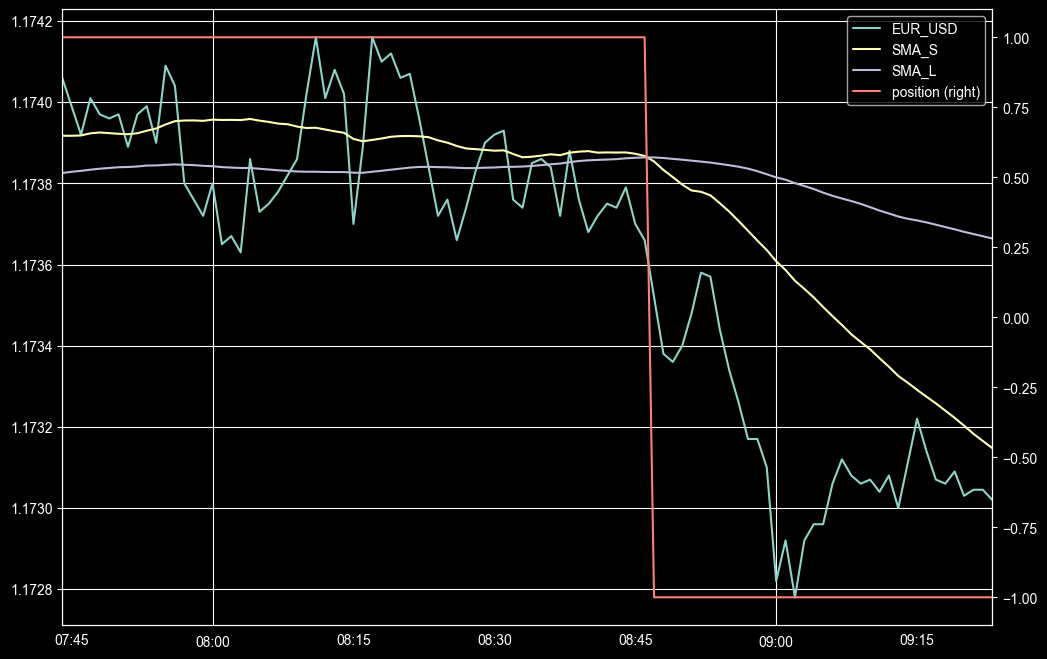

In [12]:
trader.data.tail(100).plot(figsize = (12, 8), secondary_y = "position")
plt.show()